Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Modos de vibración en una membrana circular

Para encontrar los modos de vibración de una membrana circular,
debemos resolver el siguiente problema de valores propios

$$- \nabla^2 u(x, y) = k^2 u(x, y)\quad \forall\, x^2 + y^2 < 1$$

con $u = 0$ en la frontera.

Podemos resolver este problema utilizando residuoso ponderados.
En este notebook usaremos el método de Galerkin y el problema resultante
es

$$-\int\limits_\Omega \phi_i(x, y) \nabla^2 u(x, y)  \mathrm{d}\Omega
= k^2\int\limits_\Omega \phi_i(x, y) u(x, y) \mathrm{d}\Omega\quad \forall \phi_i \in V\, ,$$

que puede reescribirse como

$$\int\limits_\Omega \nabla \phi_i(x, y) \cdot \nabla u(x, y) \mathrm{d}\Omega
= k^2\int\limits_\Omega \phi_i(x, y) u(x, y) \mathrm{d}\Omega\quad \forall \phi_i \in V\, ,$$

después de integrar por partes. También podemos escribir este problema como

$$\left\langle \nabla \phi_i, \nabla u\right\rangle
= k^2\left\langle \phi_i, u\right\rangle\quad \forall \phi_i \in V\, .$$

La función la aproximaremos de la siguienta forma

$$u_N(x) = \sum_{j=0}^N c_j \phi_i(x, y) = (x^2 + y^2 - 1)\left[c_0
+  c_1 x + c_2 y + c_3 x^2 + c_4 xy + c_5 y^2 + \cdots \right]\, ,$$

en donde vemos que esta función satisface las condiciones de frontera.

Si remplazamos en la expresión anterior, tendríamos

$$\sum_{j=0}^N \left\langle \nabla \phi_i, \nabla \phi_j\right\rangle c_j
= k^2 \sum_{j=0}^N \left\langle \phi_i, \phi_j\right\rangle c_j\quad \forall \phi_i \in V\, ,$$

que puede escribirse matricialmente como

$$[K]\{c\} = k^2[M]\{c\}\, ,$$

que es un problema de valores propios y tiene soluciones no nulas cuando

$$\det(K - k^2 M) = 0\, .$$

Este problema tiene como solución analítica los siguientes vectores propios
(en coordenadas polares):

$$u_{nm}(r, \theta) = J_m(\lambda_{mn} r) (C \cos m\theta + D \sin m\theta)\quad m=0, 1,\dots,\, n=1, 2,\dots$$

donde $\lambda_{mn}$ es el n-ésimo cero de la función $J_m$ de Bessel. Estos son los valores propios
en este caso.

Dada la simetría del problema, sería mucho más simple trabajarlo en coordenadas polares.
En donde podríamos usar senos y cosenos para la parte angular para garantizar la periodicidad.
Para la parte radial podríamos usar una base polinomial, por ejemplo. Sin embargo, usaremos
coordenadas cartesianas como ejercicio académico.

In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
from sympy import *
from sympy.plotting import plot3d

In [4]:
init_session()

# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

IPython console for SymPy 1.14.0 (Python 3.14.4-64-bit) (ground types: gmpy)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.14.0/



In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn_zeros
from scipy.linalg import eigvalsh, eigh

In [6]:
def poli_completo(x, y, n):
    """
    Devuelve la base monomial para el polinomio
    completo en x e y de orden n.

    Parámetros
    ----------
    x : símbolo de SymPy.
        Variable del polinomio.
    y : símbolo de SymPy.
        Variable del polinomio.
    n : int
        Orden del polinomio.

    Retorna
    -------
    w : list
        Elementos de la base monomial
        para el polinomio en x e y.
    c : tuple
        Coeficientes para la base
    """
    nfun = (n + 1) * (n + 2) // 2 # n-ésimo número triangular
    c = symbols('c:%d' % (nfun))
    w = []
    for i in range(0, n + 1):
        for j in range(0, i + 1):
            w.append(x**(i - j) * y**j)
    return w, c

In [7]:
b = x**2 + y**2 - 1
w, c = poli_completo(x, y, 3)
w = [b * fun for fun in w] 

In [8]:
nterms = len(w)
nterms

Acá podemos sacar ventaja del cálculo simbólico para calcular las derivadas.
Sin embargo, haremos las integrales numéricamente.

In [9]:
H = Matrix(w)

In [10]:
D = Matrix(w).jacobian([x, y])

In [11]:
K_int = expand(D * D.T)
M_int = expand(H * H.T)

In [12]:
# Esta celda permite calcular las integrales analíticamente.
# Esto no es recomendable porque es muy lento.

#K = K_int.integrate((y, -sqrt(1 - x**2), sqrt(1 - x**2))).integrate((x, -1, 1))
#M = M_int.integrate((y, -sqrt(1 - x**2), sqrt(1 - x**2))).integrate((x, -1, 1))

## Integración numérica

La integración numérica la realizamos con una
regla tomada de un artículo reciente.

In [13]:
K_int_n = lambdify((x, y), K_int, "numpy")
M_int_n = lambdify((x, y), M_int, "numpy")

In [14]:
"""
Pesos y coordenadas tomadas del siguiente artículo

Takaki, N., Forbes, G. W., & Rolland, J. P. (2022). Schemes for
cubature over the unit disk found via numerical optimization.
Journal of Computational and Applied Mathematics, 407, 114076.
https://doi.org/10.1016/j.cam.2021.114076
"""

R_GAUSS = np.array([
    0.000000000000000,
    0.363775420550028,
    0.601744604816974,
    0.678087439319387,
    0.827920982305579,
    0.842372199542979,
    0.893306018833271,
    0.965628629843171,
    0.972104010066202,
    0.982771494440792,])

T_GAUSS = np.array([
    0.000000000000000,      
    0.000000000000000,
    0.518032211681943,
    -0.010917514653234,
    0.355384455969964, 
    0.724984830394064, 
    0.038507776114625, 
    0.429897101117210, 
    0.778946956506373, 
    0.089653787780584])

W_GAUSS = np.array([
    0.019985648352286,
    0.109390374900056,
    0.089605867922125,
    0.080901543010582,
    0.054662924040364,
    0.056341227935879,
    0.042520120571368,
    0.029311953277726,
    0.024671001837889,
    0.016208113750023])

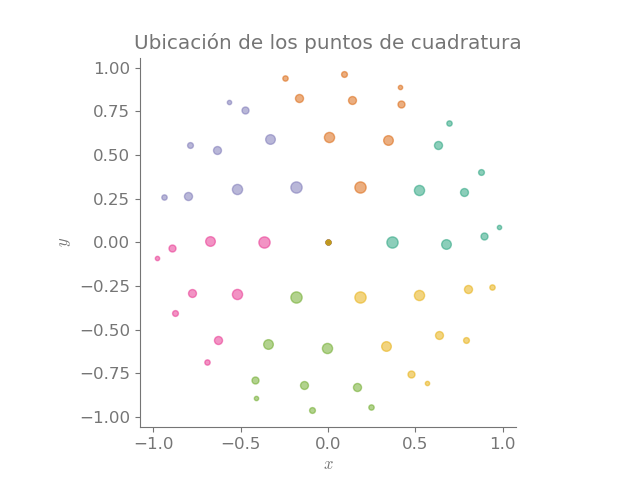

In [15]:
K_n = np.zeros_like(K_int_n(0.0, 0.0))
M_n = np.zeros_like(K_int_n(0.0, 0.0))

plt.figure()
for cont in range(6):
    colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]
    for wi, ri, ti in zip(W_GAUSS, R_GAUSS, T_GAUSS):
        ti = cont * np.pi/3 + ti
        xi = ri * np.cos(ti)
        yi = ri * np.sin(ti)
        K_n += wi * K_int_n(xi, yi)
        M_n += wi * M_int_n(xi, yi)

        plt.scatter(xi, yi, s=600*wi, c=colors[cont],
                alpha=0.5)
        

plt.title("Ubicación de los puntos de cuadratura")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.axis("image");

## Solución del problema de valores propios

In [16]:
evals_ex = np.sort(np.concatenate([jn_zeros(k, 2*nterms) for k in range(2*nterms + 1)]))
evals_ex[:nterms]

array([2.40482556, 3.83170597, 5.1356223 , 5.52007811, 6.3801619 ,
       7.01558667, 7.58834243, 8.41724414, 8.65372791, 8.77148382])

In [17]:
evals, evecs = eigh(K_n, M_n)
evals**0.5

array([2.40502147, 3.83428986, 3.83428986, 5.47722558, 5.47722558,
       6.07309957, 6.92820323, 6.92820323, 8.08073148, 8.08073148])

In [18]:
evecs_sym = Matrix(evecs).T * H

## Visualización de la solución

In [19]:
evec0_num = lambdify((x, y), evecs_sym[0])
evec3_num = lambdify((x, y), evecs_sym[3])

In [20]:
EN_DISCO = True

if EN_DISCO:
    # Hace la rejilla en coordenadas polares
    r_eval, th_eval = np.mgrid[0:1:201j, 0:2*np.pi:101j]
    x_eval = r_eval * np.cos(th_eval)
    y_eval = r_eval * np.sin(th_eval)
else:
    # Hace la rejilla en coordenadas cartesias
    # y aplica una máscara para x**2 + y**2 > 1
    x_eval, y_eval = np.mgrid[-1:1:501j, -1:1:501j]
    x_eval[x_eval**2 + y_eval**2 > 1] = np.nan
    y_eval[x_eval**2 + y_eval**2 > 1] = np.nan

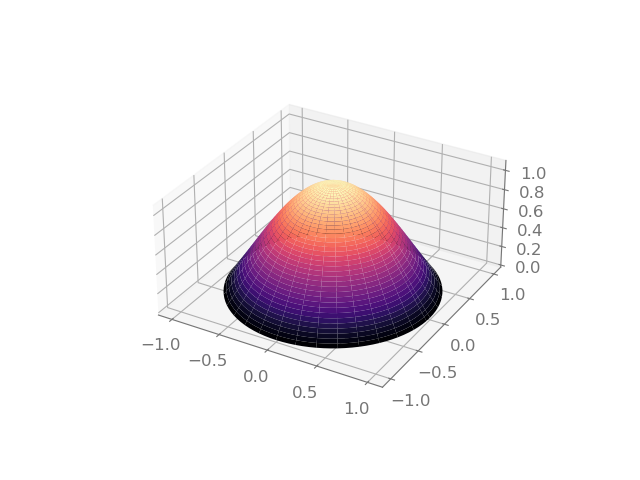

In [21]:
fig0 = plt.figure()
ax0 = fig0.add_subplot(projection='3d')
ax0.plot_surface(x_eval, y_eval, -evec0_num(x_eval, y_eval), cmap="magma")
plt.axis("image");

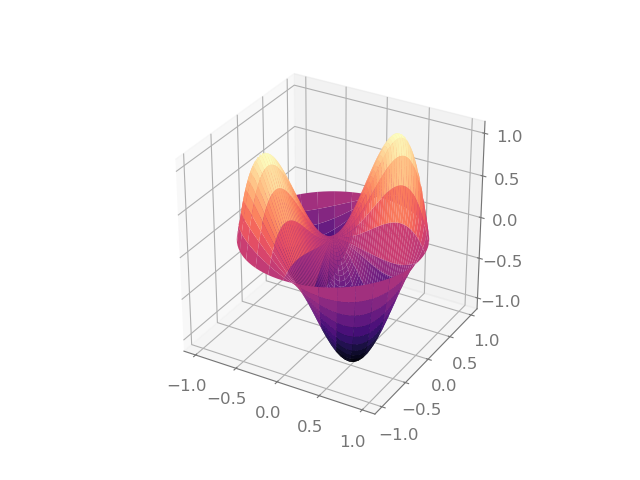

In [22]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(projection='3d')
ax1.plot_surface(x_eval, y_eval, evec3_num(x_eval, y_eval), cmap="magma",
                linewidth=0.2, antialiased=True)
plt.axis("image")